In [99]:
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)


from ISLP import confusion_table

In [100]:


df = pd.read_csv("data/processed_data.csv")
df.head()

,legId,searchDate,flightDate,startingAirport,destinationAirport,fareBasisCode,travelDuration,elapsedDays,isBasicEconomy,isRefundable,...,segmentsArrivalTimeEpochSeconds,segmentsArrivalTimeRaw,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsEquipmentDescription,segmentsDurationInSeconds,segmentsDistance,segmentsCabinCode
0,65a8a691c4d77487a439d6f44c219a39,2022-04-17,2022-04-21,LGA,DFW,UA3NA0BQ,PT5H45M,0,True,False,...,1650551340||1650563100,2022-04-21T10:29:00.000-04:00||2022-04-21T12:4...,ATL||DFW,LGA||ATL,Delta||Delta,DL||DL,Airbus A321||Airbus A321,8940||8520,762||725,coach||coach
1,1ad3c9a84f803cc98028ba8c67f35941,2022-04-18,2022-04-24,ATL,LGA,H3AHZNN1,PT2H22M,0,False,False,...,1650853920,2022-04-24T22:32:00.000-04:00,LGA,ATL,American Airlines,AA,Embraer 170,8520,762,coach
2,510f3a1255b9843a8eae48032b191faf,2022-04-17,2022-04-22,OAK,LAX,YH0OASMR,PT7H11M,0,False,False,...,1650678600||1650697140,2022-04-22T18:50:00.000-07:00||2022-04-22T23:5...,SEA||ONT,OAK||SEA,Alaska Airlines||Alaska Airlines,AS||AS,Embraer 175||Airbus A320,7320||8940,672||956,coach||coach
3,ca0fb1ee992f752bbfdcd03a8b3e8ed0,2022-04-17,2022-05-18,LGA,SFO,MAUTA5MC,PT10H22M,0,False,False,...,1652914020||1652941920,2022-05-18T18:47:00.000-04:00||2022-05-18T23:3...,ATL||SFO,LGA||ATL,Delta||Delta,DL||DL,Airbus A321||Boeing 757-300,9420||18600,762||2135,coach||coach
4,5f7a29384cea410317ca308d2e065059,2022-04-17,2022-05-06,SFO,BOS,E0AJZNN1,PT8H29M,1,False,False,...,1651919400||1651929660,2022-05-07T06:30:00.000-04:00||2022-05-07T09:2...,JFK||BOS,SFO||JFK,JetBlue Airways||JetBlue Airways,B6||B6,Airbus A319-321||AIRBUS INDUSTRIE A321 SHARKLETS,20280||4560,2566||185,coach||coach


In [101]:
df =  df.sample(frac=0.05, random_state=42)

In [102]:
# Check dimensions
#print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Overview of column types and missing values
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 205347 entries, 1042959 to 1887118
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   legId                              205347 non-null  object 
 1   searchDate                         205347 non-null  object 
 2   flightDate                         205347 non-null  object 
 3   startingAirport                    205347 non-null  object 
 4   destinationAirport                 205347 non-null  object 
 5   fareBasisCode                      205347 non-null  object 
 6   travelDuration                     205347 non-null  object 
 7   elapsedDays                        205347 non-null  int64  
 8   isBasicEconomy                     205347 non-null  bool   
 9   isRefundable                       205347 non-null  bool   
 10  isNonStop                          205347 non-null  bool   
 11  baseFare                           20

In [103]:
df.describe()

,elapsedDays,baseFare,totalFare,seatsRemaining,totalTravelDistance
count,205347.000000,205347.000000,205347.000000,205347.000000,190092.000000
mean,0.149488,292.745734,340.462618,5.976381,1609.101261
std,0.356611,183.535821,196.420323,2.878257,857.259666
min,0.000000,0.410000,19.590000,0.000000,89.000000
25%,0.000000,159.000000,197.100000,4.000000,876.000000
50%,0.000000,259.530000,303.620000,7.000000,1464.000000
75%,0.000000,398.140000,452.700000,9.000000,2417.000000
max,2.000000,4407.440000,4752.600000,10.000000,4498.000000


In [104]:
df.isnull().sum()

legId                                    0
searchDate                               0
flightDate                               0
startingAirport                          0
destinationAirport                       0
fareBasisCode                            0
travelDuration                           0
elapsedDays                              0
isBasicEconomy                           0
isRefundable                             0
isNonStop                                0
baseFare                                 0
totalFare                                0
seatsRemaining                           0
totalTravelDistance                  15255
segmentsDepartureTimeEpochSeconds        0
segmentsDepartureTimeRaw                 0
segmentsArrivalTimeEpochSeconds          0
segmentsArrivalTimeRaw                   0
segmentsArrivalAirportCode               0
segmentsDepartureAirportCode             0
segmentsAirlineName                      0
segmentsAirlineCode                      0
segmentsEqu

In [105]:
df.nunique().sort_values()

isNonStop                                 2
isRefundable                              2
isBasicEconomy                            2
elapsedDays                               3
seatsRemaining                           11
startingAirport                          16
destinationAirport                       16
segmentsCabinCode                        30
segmentsAirlineName                     105
segmentsAirlineCode                     105
searchDate                              171
flightDate                              217
travelDuration                         1351
totalTravelDistance                    2479
segmentsDepartureAirportCode           3230
segmentsArrivalAirportCode             3303
segmentsEquipmentDescription           3654
baseFare                               6022
segmentsDistance                       7472
fareBasisCode                          7813
totalFare                             11494
segmentsDurationInSeconds             46060
segmentsDepartureTimeEpochSecond

In [106]:
# Missing value Ratio
missing_ratio = df.isnull().mean().sort_values(ascending=False) * 100
missing_ratio = missing_ratio[missing_ratio > 0]
missing_ratio


totalTravelDistance             7.428889
segmentsEquipmentDescription    1.905555
segmentsDistance                1.023633
dtype: float64

In [107]:
# Find duplicates
duplicates = df[df.duplicated()]
ratio = len(duplicates) / len(df) * 100
print(f"There are {len(duplicates)} out of {len(df)} rows, representing {ratio:.2f}%")


There are 256 out of 205347 rows, representing 0.12%


In [108]:
# Ratio is low, drop duplicates
df = df.drop_duplicates()
duplicates = df[df.duplicated()]
ratio = len(duplicates) / len(df) * 100
print(f"There are {len(duplicates)} out of {len(df)} rows, representing {ratio:.2f}%")

There are 0 out of 205091 rows, representing 0.00%


### Data Cleaning

In [109]:
# Drop unecessary segment columns
unecessary_col = ['segmentsDepartureTimeEpochSeconds', 'segmentsArrivalTimeEpochSeconds', 'segmentsAirlineCode', 
                  'segmentsEquipmentDescription', 'segmentsEquipmentDescription', 'fareBasisCode', 'segmentsDurationInSeconds', 'segmentsDistance']
df = df.drop(columns = unecessary_col)

In [110]:
# show columns search date and flight data
# diff between search date and flight date

df[['searchDate', 'flightDate']].head()
df['searchDate'] = pd.to_datetime(df['searchDate'])
df['flightDate'] = pd.to_datetime(df['flightDate'])
df['date_diff'] = (df['flightDate'] - df['searchDate']).dt.days
df.describe()


,searchDate,flightDate,elapsedDays,baseFare,totalFare,seatsRemaining,totalTravelDistance,date_diff
count,205091,205091,205091.000000,205091.000000,205091.000000,205091.000000,189857.000000,205091.000000
mean,2022-07-13 21:37:43.254848,2022-08-09 17:48:12.150313472,0.149485,292.735894,340.451497,5.976601,1609.069184,26.840612
min,2022-04-16 00:00:00,2022-04-17 00:00:00,0.000000,0.410000,19.590000,0.000000,89.000000,1.000000
25%,2022-06-05 00:00:00,2022-07-01 00:00:00,0.000000,159.000000,197.100000,4.000000,876.000000,13.000000
50%,2022-07-16 00:00:00,2022-08-14 00:00:00,0.000000,259.530000,303.700000,7.000000,1464.000000,26.000000
75%,2022-08-23 00:00:00,2022-09-18 00:00:00,0.000000,398.140000,452.700000,9.000000,2417.000000,40.000000
max,2022-10-05 00:00:00,2022-11-19 00:00:00,2.000000,4407.440000,4752.600000,10.000000,4498.000000,60.000000
std,NaN,NaN,0.356608,183.484098,196.363650,2.878256,857.232738,16.314816


In [111]:
df.columns.tolist()

['legId',
 'searchDate',
 'flightDate',
 'startingAirport',
 'destinationAirport',
 'travelDuration',
 'elapsedDays',
 'isBasicEconomy',
 'isRefundable',
 'isNonStop',
 'baseFare',
 'totalFare',
 'seatsRemaining',
 'totalTravelDistance',
 'segmentsDepartureTimeRaw',
 'segmentsArrivalTimeRaw',
 'segmentsArrivalAirportCode',
 'segmentsDepartureAirportCode',
 'segmentsAirlineName',
 'segmentsCabinCode',
 'date_diff']

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205091 entries, 1042959 to 1887118
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   legId                         205091 non-null  object        
 1   searchDate                    205091 non-null  datetime64[ns]
 2   flightDate                    205091 non-null  datetime64[ns]
 3   startingAirport               205091 non-null  object        
 4   destinationAirport            205091 non-null  object        
 5   travelDuration                205091 non-null  object        
 6   elapsedDays                   205091 non-null  int64         
 7   isBasicEconomy                205091 non-null  bool          
 8   isRefundable                  205091 non-null  bool          
 9   isNonStop                     205091 non-null  bool          
 10  baseFare                      205091 non-null  float64       
 11  totalFare  

In [113]:
SEP = '||'

# Extract first departure and last arrival
dep_first_raw = (
    df['segmentsDepartureTimeRaw']
    .astype(str)
    .str.split(SEP, regex=False)
    .str.get(0)
    .str.strip()
)

arr_last_raw = (
    df['segmentsArrivalTimeRaw']
    .astype(str)
    .str.split(SEP, regex=False)
    .str.get(-1)
    .str.strip()
)

# Convert to proper datetimes
dep_dt = pd.to_datetime(dep_first_raw, utc=True, errors='coerce')
arr_dt = pd.to_datetime(arr_last_raw,  utc=True, errors='coerce')

# Extract only the time part 
df['itineraryDeparture_time'] = dep_dt.dt.time
df['itineraryArrival_time']   = arr_dt.dt.time
df = df.drop(columns = ['segmentsDepartureTimeRaw', 'segmentsArrivalTimeRaw' ])

In [114]:
# Transfrom data columns into correct data types (no "object")
df['searchDate'] = pd.to_datetime(df['searchDate'])
df['flightDate'] = pd.to_datetime(df['flightDate'])

In [115]:
# transform bool columns to int (only convert columns that actually exist)
bool_cols = ['isBasicEconomy', 'isRefundable', 'isNonStop']
bool_cols_existing = [c for c in bool_cols if c in df.columns]

for col in bool_cols_existing:
    df[col] = df[col].astype(int)

df.head()

,legId,searchDate,flightDate,startingAirport,destinationAirport,travelDuration,elapsedDays,isBasicEconomy,isRefundable,isNonStop,...,totalFare,seatsRemaining,totalTravelDistance,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsCabinCode,date_diff,itineraryDeparture_time,itineraryArrival_time
1042959,476b78efd396326a49ab6c014062580d,2022-06-05,2022-06-08,BOS,OAK,PT17H51M,0,0,0,0,...,829.71,9,2945.0,ORD||LAX||OAK,BOS||ORD||LAX,United||United||Delta,coach||coach||coach,3,11:30:00,05:21:00
1437841,f51769cb2653b33e5cfa08c03f807e60,2022-06-23,2022-06-29,DFW,DTW,PT2H41M,0,0,0,1,...,379.60,6,995.0,DTW,DFW,Delta,coach,6,23:39:00,02:20:00
1067453,70a386ff829092750869136b4c710568,2022-06-08,2022-06-14,LAX,CLT,PT10H59M,0,0,0,0,...,702.10,1,2275.0,AUS||ATL||CLT,LAX||AUS||ATL,Alaska Airlines||Delta||Delta,coach||coach||coach,6,15:20:00,02:19:00
198386,15a2d8dc5cb7b3ec0210f1f87adcbade,2022-04-23,2022-06-12,IAD,LAX,PT14H50M,0,0,0,0,...,627.20,7,2679.0,EWR||LAX,IAD||EWR,United||Alaska Airlines,coach||coach,50,11:33:00,02:23:00
2674967,5a26f39498d66b0836491c0aebb4f080,2022-08-07,2022-09-06,JFK,DEN,PT8H43M,0,0,0,0,...,601.60,9,1694.0,DCA||DEN,JFK||DCA,Delta||United,coach||coach,30,15:22:00,00:05:00


In [116]:
# Clean Travel Duration column
def parse_travel_duration(s):
    if pd.isnull(s):
        return None
    
    # duration pattern 
    pattern = (
        r'P'                            
        r'(?:(\d+)D)?'                  
        r'(?:(\d+)W)?'                  
        r'(?:T(?:(\d+)H)?(?:(\d+)M)?)?' 
    )
    match = re.match(pattern, s)
    if not match:
        return None
    
    days = int(match.group(1)) if match.group(1) else 0
    weeks = int(match.group(2)) if match.group(2) else 0
    hours = int(match.group(3)) if match.group(3) else 0
    minutes = int(match.group(4)) if match.group(4) else 0

    total_hours = weeks * 7 * 24 + days * 24 + hours + minutes / 60
    return total_hours

# Apply it
df['travelDuration_hours'] = df['travelDuration'].apply(parse_travel_duration)
df = df.drop(columns='travelDuration')

In [117]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 205091 entries, 1042959 to 1887118
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   legId                         205091 non-null  object        
 1   searchDate                    205091 non-null  datetime64[ns]
 2   flightDate                    205091 non-null  datetime64[ns]
 3   startingAirport               205091 non-null  object        
 4   destinationAirport            205091 non-null  object        
 5   elapsedDays                   205091 non-null  int64         
 6   isBasicEconomy                205091 non-null  int64         
 7   isRefundable                  205091 non-null  int64         
 8   isNonStop                     205091 non-null  int64         
 9   baseFare                      205091 non-null  float64       
 10  totalFare                     205091 non-null  float64       
 11  seatsRemain

In [118]:
# Most common origin airports or cities
df['startingAirport'].value_counts()


startingAirport
LAX    20150
LGA    14891
BOS    14680
DFW    14320
SFO    14168
ORD    13828
CLT    13544
ATL    13401
MIA    12292
PHL    11890
DEN    11533
DTW    11181
JFK    11015
EWR     9905
OAK     9643
IAD     8650
Name: count, dtype: int64

In [119]:
# get minimum and maximum values for dates
print(f"Search Date Range: {df['searchDate'].min()} to {df['searchDate'].max()}")
print(f"Flight Date Range: {df['flightDate'].min()} to {df['flightDate'].max()}")
print(f"Date Difference Range: {df['date_diff'].min()} to {df['date_diff'].max()}")

Search Date Range: 2022-04-16 00:00:00 to 2022-10-05 00:00:00
Flight Date Range: 2022-04-17 00:00:00 to 2022-11-19 00:00:00
Date Difference Range: 1 to 60


#### Missing Values

In [120]:
#====== Check Missing Values for 'dating_sample':

#compute total # of rows with missing value
missing_total= df.isnull().any(axis=1).sum()

#compute total # of row
total_record= df.any(axis=1).sum()

#output
print('Out of', total_record, 'records', missing_total,'are missing')

#total # of missing values within each variable
missing_counts = df.isnull().sum()


# calculate ratio (proportion of missing values)
missing_ratio = (missing_counts/total_record)*100



# combine missing_counts, calculate ratio (as two columnes) into a summary table
missing_summary = pd.DataFrame({
    'MissingCount': missing_counts,
    'MissingRatio': missing_ratio
    }).sort_values(by='MissingRatio', ascending= False)

#output
missing_summary[0:10]

Out of 205091 records 15234 are missing


/var/folders/tv/ktkmfz315030nmvvnn_jwqnc0000gn/T/ipykernel_52560/2152794425.py:7: FutureWarning: 'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.
  total_record= df.any(axis=1).sum()
/var/folders/tv/ktkmfz315030nmvvnn_jwqnc0000gn/T/ipykernel_52560/2152794425.py:7: FutureWarning: 'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.
  total_record= df.any(axis=1).sum()


,MissingCount,MissingRatio
totalTravelDistance,15234,7.427922
legId,0,0.000000
seatsRemaining,0,0.000000
itineraryArrival_time,0,0.000000
itineraryDeparture_time,0,0.000000
date_diff,0,0.000000
segmentsCabinCode,0,0.000000
segmentsAirlineName,0,0.000000
segmentsDepartureAirportCode,0,0.000000
segmentsArrivalAirportCode,0,0.000000


## Multiple Linear Regression

In [121]:
# Model specification
design_1=MS(["travelDuration_hours", "seatsRemaining", 
             "totalTravelDistance", "date_diff", 'isBasicEconomy', 'isRefundable', 'isNonStop'])

#setup: recall that the data is dating_sample_original
x_reg_1= design_1.fit_transform(df)
y_1=df['totalFare']

#regression 
# Drop rows with missing values in predictors or response
valid_idx = x_reg_1.notnull().all(axis=1) & y_1.notnull()
x_reg_1_clean = x_reg_1[valid_idx]
y_1_clean = y_1[valid_idx]

result_1 = sm.OLS(y_1_clean, x_reg_1_clean).fit()

#show results
print('R-square:', round(result_1.rsquared,3))
result_1_summary=summarize(result_1)

result_1_summary


R-square: 0.385


,coef,std err,t,P>|t|
intercept,167.0845,1.568,106.565,0.0
travelDuration_hours,13.5391,0.172,78.616,0.0
seatsRemaining,4.9409,0.154,32.097,0.0
totalTravelDistance,0.0638,0.001,106.749,0.0
date_diff,-0.5987,0.022,-27.057,0.0
isBasicEconomy,-186.1783,1.050,-177.254,0.0
isRefundable,1488.1197,109.568,13.582,0.0
isNonStop,-7.6191,1.086,-7.015,0.0


In [122]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = [variance_inflation_factor(x_reg_1_clean.values, i) for i in range(x_reg_1_clean.shape[1])]


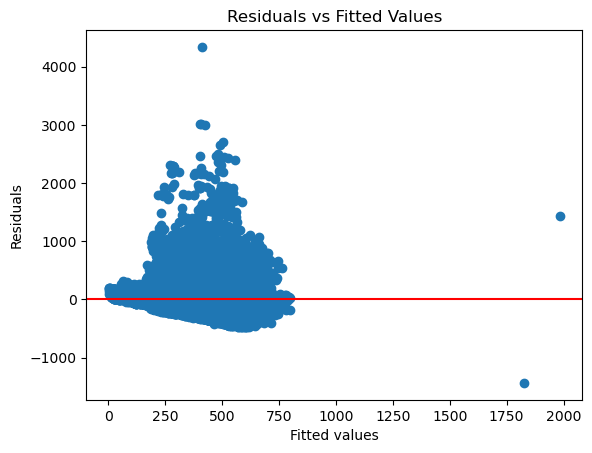

In [123]:
import matplotlib.pyplot as plt
plt.scatter(result_1.fittedvalues, result_1.resid)
plt.axhline(0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()


                            OLS Regression Results                            
Dep. Variable:              totalFare   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                 2.549e+04
Date:                Wed, 12 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:10:25   Log-Likelihood:                -98370.
No. Observations:              189857   AIC:                         1.968e+05
Df Residuals:                  189849   BIC:                         1.968e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept                5.2556 

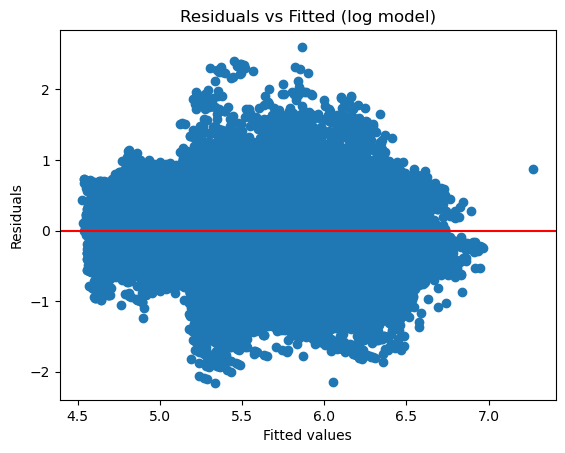

In [124]:
import numpy as np

y_log = np.log(df['totalFare'])
# Align y_log with x_reg_1_clean using valid_idx
y_log_clean = y_log[valid_idx]
result_log = sm.OLS(y_log_clean, x_reg_1_clean).fit()

print(result_log.summary())

plt.scatter(result_log.fittedvalues, result_log.resid)
plt.axhline(0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (log model)')
plt.show()


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205091 entries, 1042959 to 1887118
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   legId                         205091 non-null  object        
 1   searchDate                    205091 non-null  datetime64[ns]
 2   flightDate                    205091 non-null  datetime64[ns]
 3   startingAirport               205091 non-null  object        
 4   destinationAirport            205091 non-null  object        
 5   elapsedDays                   205091 non-null  int64         
 6   isBasicEconomy                205091 non-null  int64         
 7   isRefundable                  205091 non-null  int64         
 8   isNonStop                     205091 non-null  int64         
 9   baseFare                      205091 non-null  float64       
 10  totalFare                     205091 non-null  float64       
 11  seatsRemain

In [126]:
df['duration_nonStop'] = df['travelDuration_hours'] * df['isNonStop']

In [127]:
import statsmodels.api as sm

X = df[['travelDuration_hours', 'seatsRemaining', 
        'totalTravelDistance', 'date_diff', 'isBasicEconomy',
        'isRefundable', 'isNonStop', 'duration_nonStop']]

y = df['totalFare']

# clean rows
df_clean = pd.concat([X, y], axis=1).dropna()
X_clean = sm.add_constant(df_clean[X.columns])
y_clean = df_clean['totalFare']

model2 = sm.OLS(y_clean, X_clean).fit()
print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:              totalFare   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                 1.489e+04
Date:                Wed, 12 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:10:31   Log-Likelihood:            -1.2268e+06
No. Observations:              189857   AIC:                         2.454e+06
Df Residuals:                  189848   BIC:                         2.454e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  172.2129 

                            OLS Regression Results                            
Dep. Variable:              totalFare   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                 2.283e+04
Date:                Wed, 12 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:10:33   Log-Likelihood:                -97291.
No. Observations:              189857   AIC:                         1.946e+05
Df Residuals:                  189848   BIC:                         1.947e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

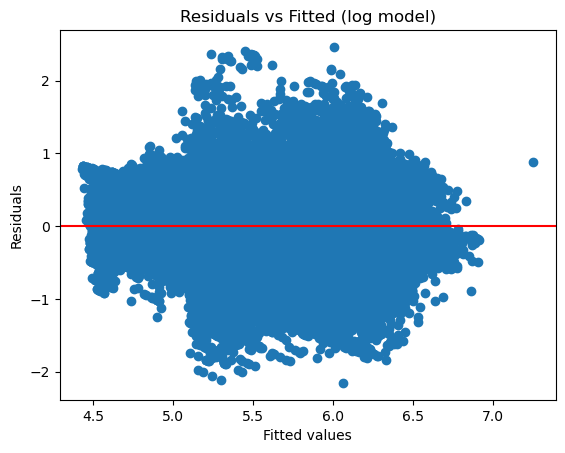

In [128]:
df_clean = df.assign(
    travelDuration_times_nonstop = df['travelDuration_hours'] * df['isNonStop'].astype(int)
).dropna(subset=[
    'travelDuration_hours','seatsRemaining','totalTravelDistance','date_diff',
    'isBasicEconomy','isRefundable','isNonStop','travelDuration_times_nonstop','totalFare'
])

X = sm.add_constant(df_clean[[
    'travelDuration_hours','seatsRemaining','totalTravelDistance','date_diff',
    'isBasicEconomy','isRefundable','isNonStop','travelDuration_times_nonstop'
]])

y_log = np.log(df_clean['totalFare'])

model2_log = sm.OLS(y_log, X).fit()
print(model2_log.summary())

plt.scatter(model2_log.fittedvalues, model2_log.resid)
plt.axhline(0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (log model)')
plt.show()

In [ ]:
# Model with Categorical Variables
print("=" * 80)
print("MODEL WITH CATEGORICAL VARIABLES")
print("=" * 80)

# Create a clean dataset with categorical encoding
df_categorical = df.assign(
    travelDuration_times_nonstop = df['travelDuration_hours'] * df['isNonStop'].astype(int)
).dropna(subset=[
    'travelDuration_hours','seatsRemaining','totalTravelDistance','date_diff',
    'isBasicEconomy','isRefundable','isNonStop','travelDuration_times_nonstop','totalFare',
    'startingAirport', 'destinationAirport', 'segmentsAirlineName'
])

# Create dummy variables for categorical features
airport_dummies = pd.get_dummies(df_categorical['startingAirport'], prefix='origin', drop_first=True, dtype=float)
dest_dummies = pd.get_dummies(df_categorical['destinationAirport'], prefix='dest', drop_first=True, dtype=float)

# For airlines, let's take the first airline in the segments
df_categorical['primary_airline'] = df_categorical['segmentsAirlineName'].str.split('||').str[0]
airline_dummies = pd.get_dummies(df_categorical['primary_airline'], prefix='airline', drop_first=True, dtype=float)

# Combine all features - ensure all are numeric
X_categorical = pd.concat([
    df_categorical[['travelDuration_hours','seatsRemaining','totalTravelDistance','date_diff',
                    'isBasicEconomy','isRefundable','isNonStop','travelDuration_times_nonstop']].astype(float),
    airport_dummies,
    dest_dummies,
    airline_dummies
], axis=1)

# Add constant and ensure it's float
X_categorical = sm.add_constant(X_categorical, has_constant='add')
y_categorical = df_categorical['totalFare'].astype(float)

# Fit the model
model_categorical = sm.OLS(y_categorical, X_categorical).fit()

print(f"\nNumber of features: {X_categorical.shape[1]}")
print(f"Number of observations: {X_categorical.shape[0]}")
print(f"\nR-squared: {model_categorical.rsquared:.4f}")
print(f"Adjusted R-squared: {model_categorical.rsquared_adj:.4f}")
print("\n" + model_categorical.summary().as_text())

In [ ]:
# Comparison Plot
import matplotlib.pyplot as plt

# Create comparison of models
models_comparison = {
    'Basic Model': 0.385,
    'Log Transform': 0.485,
    'With Interaction': 0.490,
    'With Categoricals': model_categorical.rsquared
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = ax1.bar(models_comparison.keys(), models_comparison.values(), color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('R-squared', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison: R-squared Values', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontweight='bold')

# Residual plot for categorical model
ax2.scatter(model_categorical.fittedvalues, model_categorical.resid, alpha=0.5, s=10)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Fitted Values', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuals', fontsize=12, fontweight='bold')
ax2.set_title('Residuals vs Fitted (Categorical Model)', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("IMPROVEMENT SUMMARY")
print("=" * 80)
improvement = (model_categorical.rsquared - 0.385) / 0.385 * 100
print(f"Improvement from basic model: {improvement:.2f}%")
print(f"R-squared increased from 0.385 to {model_categorical.rsquared:.4f}")
print(f"This means the model now explains {model_categorical.rsquared*100:.2f}% of the variance in flight prices")

In [ ]:
# Prepare Time Series Data for R
print("=" * 80)
print("PREPARING TIME SERIES DATA FOR R")
print("=" * 80)

# Create a copy of the dataframe
df_ts = df.copy()

# Ensure dates are datetime
df_ts['searchDate'] = pd.to_datetime(df_ts['searchDate'])
df_ts['flightDate'] = pd.to_datetime(df_ts['flightDate'])

# Create time-based features
df_ts['search_year'] = df_ts['searchDate'].dt.year
df_ts['search_month'] = df_ts['searchDate'].dt.month
df_ts['search_week'] = df_ts['searchDate'].dt.isocalendar().week
df_ts['search_day'] = df_ts['searchDate'].dt.day
df_ts['search_dayofweek'] = df_ts['searchDate'].dt.dayofweek  # Monday=0, Sunday=6
df_ts['search_quarter'] = df_ts['searchDate'].dt.quarter

df_ts['flight_year'] = df_ts['flightDate'].dt.year
df_ts['flight_month'] = df_ts['flightDate'].dt.month
df_ts['flight_week'] = df_ts['flightDate'].dt.isocalendar().week
df_ts['flight_day'] = df_ts['flightDate'].dt.day
df_ts['flight_dayofweek'] = df_ts['flightDate'].dt.dayofweek
df_ts['flight_quarter'] = df_ts['flightDate'].dt.quarter

# Create aggregated time series datasets

# 1. Daily aggregation by search date
daily_ts = df_ts.groupby('searchDate').agg({
    'totalFare': ['mean', 'median', 'std', 'min', 'max', 'count'],
    'baseFare': ['mean', 'median'],
    'totalTravelDistance': 'mean',
    'seatsRemaining': 'mean',
    'isBasicEconomy': 'mean',
    'isNonStop': 'mean'
}).reset_index()
daily_ts.columns = ['_'.join(col).strip('_') for col in daily_ts.columns.values]

# 2. Weekly aggregation
df_ts['search_yearweek'] = df_ts['searchDate'].dt.to_period('W').astype(str)
weekly_ts = df_ts.groupby('search_yearweek').agg({
    'totalFare': ['mean', 'median', 'std', 'count'],
    'baseFare': 'mean',
    'totalTravelDistance': 'mean',
    'seatsRemaining': 'mean'
}).reset_index()
weekly_ts.columns = ['_'.join(col).strip('_') for col in weekly_ts.columns.values]

# 3. Monthly aggregation
df_ts['search_yearmonth'] = df_ts['searchDate'].dt.to_period('M').astype(str)
monthly_ts = df_ts.groupby('search_yearmonth').agg({
    'totalFare': ['mean', 'median', 'std', 'count'],
    'baseFare': 'mean',
    'totalTravelDistance': 'mean',
    'seatsRemaining': 'mean'
}).reset_index()
monthly_ts.columns = ['_'.join(col).strip('_') for col in monthly_ts.columns.values]

# 4. Route-level time series (daily by route)
df_ts['route'] = df_ts['startingAirport'] + '_' + df_ts['destinationAirport']
route_daily_ts = df_ts.groupby(['searchDate', 'route']).agg({
    'totalFare': ['mean', 'count'],
    'baseFare': 'mean'
}).reset_index()
route_daily_ts.columns = ['_'.join(col).strip('_') for col in route_daily_ts.columns.values]

# Export to CSV files
print("\nExporting time series datasets...")

# Full dataset with time features
df_ts.to_csv('data/flight_data_with_time_features.csv', index=False)
print(f"✓ Exported full dataset: {df_ts.shape[0]} rows, {df_ts.shape[1]} columns")

# Daily aggregated
daily_ts.to_csv('data/flight_daily_timeseries.csv', index=False)
print(f"✓ Exported daily time series: {daily_ts.shape[0]} days, {daily_ts.shape[1]} columns")

# Weekly aggregated
weekly_ts.to_csv('data/flight_weekly_timeseries.csv', index=False)
print(f"✓ Exported weekly time series: {weekly_ts.shape[0]} weeks, {weekly_ts.shape[1]} columns")

# Monthly aggregated
monthly_ts.to_csv('data/flight_monthly_timeseries.csv', index=False)
print(f"✓ Exported monthly time series: {monthly_ts.shape[0]} months, {monthly_ts.shape[1]} columns")

# Route-level daily
route_daily_ts.to_csv('data/flight_route_daily_timeseries.csv', index=False)
print(f"✓ Exported route-level daily time series: {route_daily_ts.shape[0]} rows")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Date range: {df_ts['searchDate'].min()} to {df_ts['searchDate'].max()}")
print(f"Total days: {(df_ts['searchDate'].max() - df_ts['searchDate'].min()).days}")
print(f"\nFiles created in 'data/' folder:")
print("  1. flight_data_with_time_features.csv - Full dataset with time features")
print("  2. flight_daily_timeseries.csv - Daily aggregated (best for ARIMA/Prophet)")
print("  3. flight_weekly_timeseries.csv - Weekly aggregated")
print("  4. flight_monthly_timeseries.csv - Monthly aggregated")
print("  5. flight_route_daily_timeseries.csv - Daily by route")
print("\nRecommended for R time series analysis:")
print("  - Use 'flight_daily_timeseries.csv' for ARIMA, Prophet, or STL decomposition")
print("  - Use 'flight_data_with_time_features.csv' for regression with time features")

# Show preview of daily time series
print("\nPreview of daily time series:")
print(daily_ts.head(10))